In [11]:
import logging
import math

import numpy as np
import tsplib95

from TP.core.logging.observer import BestFitnessLogger
from TP.core.logging.progress import EALogger
from TP.core.multiobjective.selection.parents.operators import CrowdTournament
from TP.core.multiobjective.selection.survivors.operators import (
    NonDominanceOrdering,
)
from TP.core.variation.mutation import RSM
from TP.problems.tsp.variation.recombination import SCX
from TP.problems.vrp.NSGAII_interface import VRPNSGAIIOrchestrator
from TP.problems.vrp.utils.problem_data import VRPProblemData

logging.basicConfig(level=logging.INFO)


# Carregamento da instância TSP -> matriz de distâncias
graph = tsplib95.load('data/att48.tsp')
n = graph.dimension

dist_mtx = np.zeros((n, n), dtype=np.float64)

for i in range(n):
    for j in range(n):
        if i == j:
            dist_mtx[i, j] = (
                math.inf
            )  # Importante colocar diagonal como infinito (se não vai dar pau no DP)
        else:
            dist_mtx[i, j] = graph.get_weight(i + 1, j + 1)


coords = np.array(
    [graph.node_coords[i + 1] for i in range(n)], dtype=np.float64
)

problem_instance = VRPProblemData(
    n_vehicles=5, depot_node=0, dist_mtx=dist_mtx
)

In [12]:
pop_size = 120
tournament_size = 4
max_generations = 1200

p_c = 0.8
p_m = 0.25
p_ls = 0.4

data_logger = BestFitnessLogger()

# Imprime apenas de 100 em 100
process_logger = EALogger()

parent_selector = CrowdTournament(tournament_size=tournament_size)
survivor_selector = NonDominanceOrdering()
recombinator = SCX(dist_mtx=problem_instance.dist_mtx)
mutation_operator = RSM()

orchestrator = VRPNSGAIIOrchestrator(
    problem_instance=problem_instance,
    survivor_selector=survivor_selector,
    mutation_operator=mutation_operator,
    recombinator=recombinator,
    pop_size=pop_size,
    parent_selector=parent_selector,
    max_generations=max_generations,
    observers=[data_logger],
    loggers=[process_logger],
    p_c=p_c,
    p_m=p_m,
    p_ls=p_ls,
)

out = orchestrator.run()

INFO:TP.core.logging.progress:EA started | population_size=120
INFO:TP.core.logging.progress:Generation 100 | Best front size=8 | Pop Size=120
INFO:TP.core.logging.progress:Generation 200 | Best front size=6 | Pop Size=120
INFO:TP.core.logging.progress:Generation 300 | Best front size=5 | Pop Size=120
INFO:TP.core.logging.progress:Generation 400 | Best front size=5 | Pop Size=120
INFO:TP.core.logging.progress:Generation 500 | Best front size=10 | Pop Size=120
INFO:TP.core.logging.progress:Generation 600 | Best front size=7 | Pop Size=120
INFO:TP.core.logging.progress:Generation 700 | Best front size=5 | Pop Size=120
INFO:TP.core.logging.progress:Generation 800 | Best front size=6 | Pop Size=120
INFO:TP.core.logging.progress:Generation 900 | Best front size=6 | Pop Size=120
INFO:TP.core.logging.progress:Generation 1000 | Best front size=4 | Pop Size=120
INFO:TP.core.logging.progress:Generation 1100 | Best front size=6 | Pop Size=120
INFO:TP.core.logging.progress:Generation 1200 | Best f

In [13]:
# Auxiliary functions to make plots

from TP.core.multiobjective.individuals.representation import MOIndividual
from TP.core.state import EAState
from TP.problems.vrp.utils.best_cuts import DPFindCuts


def sample_pareto_individuals(state: EAState, k: int = 3):
    front = state.fronts[0]

    sorted_by_dist = sorted(
        front, key=lambda ind: ind.fitness.total_distance.value
    )
    sorted_by_balance = sorted(
        front, key=lambda ind: ind.fitness.max_imbalance.value
    )

    best_dist = sorted_by_dist[0]
    best_balance = sorted_by_balance[0]

    # ordenação simples para pegar intermediários
    sorted_tradeoff = sorted(
        front,
        key=lambda ind: (
            ind.fitness.total_distance.value + ind.fitness.max_imbalance.value
        ),
    )

    middle = sorted_tradeoff[len(sorted_tradeoff) // 2]

    selected = [best_dist, best_balance, middle]

    if k > 3:
        step = max(1, len(sorted_tradeoff) // k)
        selected = sorted_tradeoff[::step][:k]

    return selected


def extract_route_segments(chrm, problem_data):
    splitter = DPFindCuts()

    last_pos, vec_used, _, path_builder = splitter.builds_dp_structure(
        chrm, problem_data
    )

    segments = []
    current_loc = (last_pos, vec_used)

    while vec_used > 0:
        prev_loc = path_builder[current_loc]

        start = prev_loc[0]
        end = current_loc[0]

        segments.append((start + 1, end))  # ignora depot

        current_loc = prev_loc
        vec_used -= 1

    return list(reversed(segments))

import matplotlib.pyplot as plt


def plot_routes(
    individual: MOIndividual,
    problem_data: VRPProblemData,
    coords: np.ndarray,  # <-- vem de fora
):
    chrm = individual.chrm
    depot = problem_data.depot_node

    segments = extract_route_segments(chrm, problem_data)

    plt.figure(figsize=(8, 6))

    # depot
    x_d, y_d = coords[depot]
    plt.scatter(x_d, y_d, c="red", s=120, label="Depot", zorder=3)

    # rotas
    for i, (start, end) in enumerate(segments):
        route_nodes = chrm[start - 1 : end]

        full_route = [depot] + route_nodes + [depot]

        xs = [coords[n][0] for n in full_route]
        ys = [coords[n][1] for n in full_route]

        plt.plot(xs, ys, marker="o", label=f"Rota {i+1}")

    plt.title(
        f"Dist={individual.fitness.total_distance.value:.2f} | "
        f"Imb={individual.fitness.max_imbalance.value:.2f}"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

In [14]:
selected = sample_pareto_individuals(out)

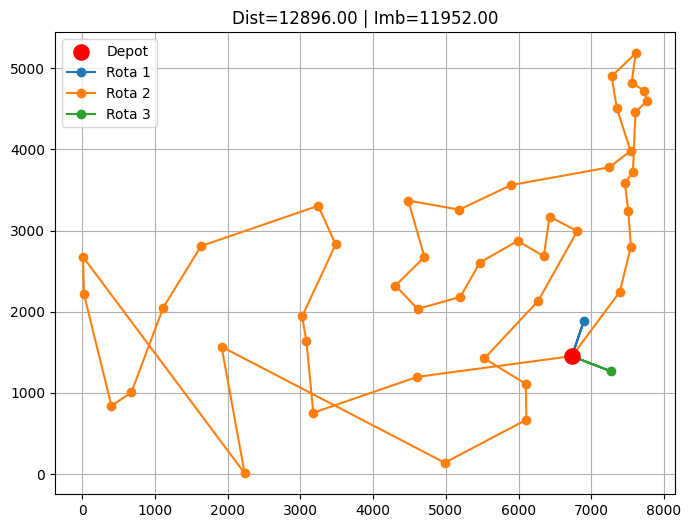

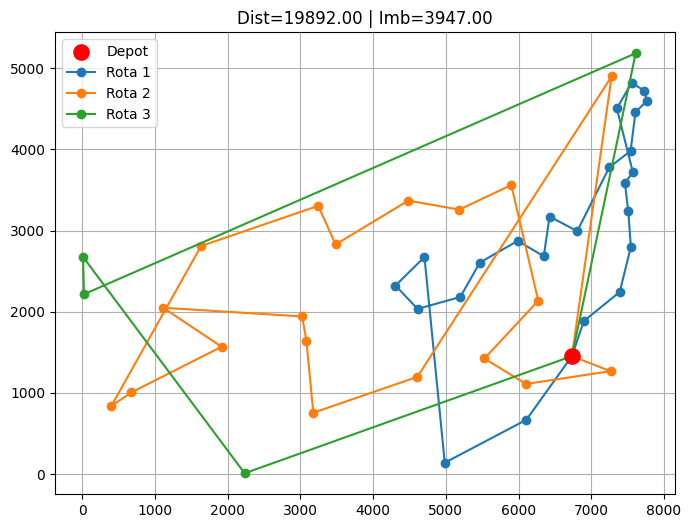

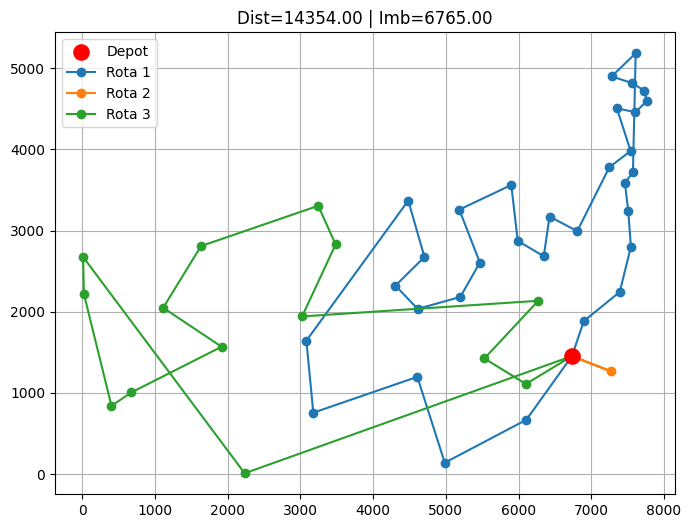

In [15]:
for ind in selected:
    plot_routes(ind, problem_instance, coords)